# 2.10. Formulas verification

Let's try to compare various formulas for relocation effect. In this model we'll perform lots of 
identical relocations for the same pair of demands, and the same n1 and n2 in from and to stations,
and then we'll check the average relocation effect.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from types import SimpleNamespace
import time

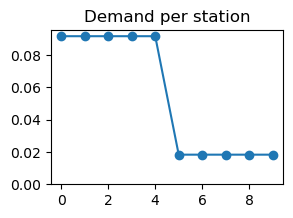

In [9]:
# Repeat the same configs as in the "optimal relo frequency" notebook

def update_config(cfg):
    # To interpret our data financially, renormalize them to typical daily values for real cities
    # cfg.cm1_factor = 20*5/max(cfg.demand) # Assume 20 trips/day from the hottest zone, and 5 €/trip CM1
    cfg.time_factor = 100/sum(cfg.demand)  # Let's insist on 100 rentals a day, to be able to directly compare different demand shapes
    cfg.cm1_factor = 5  # CM1 contribution per trip, Eur
    cfg.cm2_factor = 20  # CM2 cost of a car per day, Eur
    cfg.relo_cost = 0  # 🍎 In this model relocations are free!
    return cfg

def get_config(scenario, **kwargs):
    """Return a config of values as a SimpleNamespace."""
    d = {}
    d['scenario'] = scenario
    d['n_stations'] = 10
    d['n_cars'] = 15
    d['relo_period'] = 50

    d['n_steps_preparation'] = 20000 # For how many steps stats are NOT collected
    d['n_steps_per_experiment'] = 5000
    d['n_experiments'] = 100
    d['start_condition'] = "uniform"

    out = SimpleNamespace(**d)

    # Now set any manual corrections, if any.
    # Warning: as we're doing it here, all properties that are set afterwards are not settable via get_config(key=value) interface.
    # It's not a good design, but also this is just a notebook, not a package.
    for key, value in kwargs.items():
        setattr(out, key, value)

    # Calculate demand
    if scenario == 'linear':
        out.demand = np.arange(out.n_stations, 0, -1)
    elif scenario == 'dropoff':
        out.demand = np.array([1/(1 + i) for i in range(out.n_stations)])  # Drop-off
    elif scenario == 'steps':
        out.demand = np.zeros(out.n_stations)
        n_steps = 2  # 🍎 In this model we'll use two levels only, to make relos identical
        n_within = out.n_stations // n_steps
        for i in range(n_steps):
            j = i*n_within
            out.demand[j:min(j+n_within, out.n_stations)] = n_steps - i - 1
    elif scenario == 'cosine':
        out.demand = np.array([np.cos(i/(out.n_stations-1)*np.pi) + 1.2 for i in range(out.n_stations)])  # Hat

    out.demand = out.demand / out.demand.sum()  # First take
    out.demand = np.maximum(out.demand, 0.04)  # 🍎 Much higher level than in other models
    out.demand = out.demand / out.demand.sum() * 0.55  # Final take (the magic number makes the top demand close to 0.1)
    # We need to keep these values low enough, for our binomial process to represent a Poisson process well enough.
    # The actual scaling factor doesn't matter much for CM2 calculations, as we set the CM1 coefficient manually anyways (below)
    # The only two things that matter here are that 1) the shape of the distribution is correct,
    # 2) the values are small enough to resemble Poisson process

    out = update_config(out)
    return out

# Practical test
cfg = get_config('steps', n_stations=10)

plt.figure(figsize=(3, 2)) # Visualize demand, to be sure
plt.plot(cfg.demand, 'o-')
plt.ylim(0, None)
plt.title("Demand per station");

In [ ]:
# Main model loop

def run_model(cfg, n0=1, n=0, seed=None):
    """Main modeling loop as a method"""
    if seed is None:
        seed = int(time.time() * 1000000) % 2**32
    np.random.seed(seed)

    # Make copies of some variables for brevity reasons
    n_steps = cfg.n_steps_preparation + cfg.n_steps_per_experiment*cfg.n_experiments
    n_stations = cfg.n_stations
    demand = cfg.demand  # For shorter formulas only
    tick_length_days = demand.sum() / 200   # To recalculate n events to "daily events"
    # print(f"Time in the model (per experiment): {cfg.n_steps_per_experiment*tick_length_days:.1f} days")

    cm1 = np.zeros(shape=(cfg.n_experiments, n_stations))
    average_cars = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_attempts = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_rentals = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_relos = np.zeros(shape=(cfg.n_experiments, n_stations))
    total_effect1 = np.zeros(shape=(cfg.n_experiments))
    total_effect2 = np.zeros(shape=(cfg.n_experiments))

    # Distribute cars uniformly
    state = np.array([cfg.n_cars // cfg.n_stations]*n_stations) # Case of cars being distributed uniformly
    state[0] = state[0] + (cfg.n_cars - sum(state))  # Correction in case division failed us

    for i_step in range(n_steps):
        attempts = (np.random.uniform(size=cfg.n_stations) < demand) # If a car was ordered
        departures = attempts * (state > 0)
        destinations = np.random.choice(
            n_stations, size=n_stations, p=demand/sum(demand)) # Where a car would go if ordered
        # The formula above assumes that ultimately in and out flows for every station are balanced, so if
        # few people depart from the station (low demand), it will also be unlikely to become a destination
        # (that's why NORMALIZED demand is used as a probability parameter for random.choice)

        if (i_step >= cfg.n_steps_preparation) & ((i_step - cfg.n_steps_preparation) % cfg.n_steps_per_experiment == 0):
            i_experiment = (i_step - cfg.n_steps_preparation) // cfg.n_steps_per_experiment
            print('.', end='') # Experiment counter

        destinations[~departures] = -1 # If the car didn't leave then it doesn't arrive anywhere
        arrivals = [sum(destinations==i) for i in range(n_stations)] # Manual pivot table

        state = state - departures + arrivals

        # Potential Relocation
        # Find where to relocate from. This time around it's not about financials, but based on
        # occupancy and having different demand levels.
        # Find all zones with zone number above n_zones/2 (aka low demand) and exactly n0 cars:
        from_zones = np.where((np.arange(n_stations) >= n_stations/2) & (state == n0))[0]
        if from_zones.size > 0:
            start_relo = np.random.choice(from_zones)
        else:
            start_relo = -1  # No relos possible

        # Find all zones with zone number below n_zones/2 (aka high demand) and eactlu n cars:
        to_zones = np.where((np.arange(n_stations) < n_stations/2) & (state == n))[0]
        if to_zones.size > 0:
            end_relo = np.random.choice(to_zones)
        else:
            end_relo = -1  # No relos possible

        # If relo possible, perform the relo, count it, calculate expected demand change
        if (start_relo >= 0) & (end_relo >= 0):
            # Simple idle time difference (not accounting for other cars in the zone)
            effect1 = (n0/demand[start_relo] - (n+1)/demand[end_relo])
            # Fancier formula (trying to account for other cars)
            effect2 = (n0*(n0+1)/demand[start_relo] - (n+1)*(n+2)/demand[end_relo])/2

            state[start_relo] -= 1
            state[end_relo] += 1
            relo_happened = True
        else:
            relo_happened = False

        if i_step > cfg.n_steps_preparation: # Collect stats
            # CM1 is first shared between target andd destination, then turned from raw numbers to probabilities,
            # then  from probabilities to daily rates using time-factor, then to daily money using money factor
            cm1[i_experiment, :] += (departures + arrivals)/2/cfg.n_steps_per_experiment * cfg.time_factor * cfg.cm1_factor
            average_cars[i_experiment, :] += state/cfg.n_steps_per_experiment  # Average n cars over time
            total_attempts[i_experiment, :] += attempts*1
            total_rentals[i_experiment, :] += departures
            if relo_happened:
                total_relos[i_experiment, start_relo] += 1

                # Translate idle time effects to cm2 money
                # Option 1: fixed coefficient assuming optimal fleet
                # coeff = cfg.cm2_factor * tick_length_days  # idle time to CM2 transformation
                # Option 2: average revenue so far, per car, per tick
                coeff = (
                    cm1[i_experiment, :].sum()/(i_step - cfg.n_steps_preparation+1)/cfg.n_cars
                )

                total_effect1[i_experiment] += effect1*coeff
                total_effect2[i_experiment] += effect2*coeff

    return SimpleNamespace(
            cm1=cm1,
            average_cars=average_cars,
            n_apps=total_attempts,
            n_rentals=total_rentals,
            n_relos=total_relos,
            total_effect1=total_effect1,
            total_effect2=total_effect2,
            )

# Test
test_cfg = get_config('steps', n_experiments=1)
out = run_model(test_cfg)

print("Demand per zone: ", " ".join([f"{x:0.3f}" for x in test_cfg.demand]))
print("Total relocation starts per zone:", out.n_relos)
print("Rentals per relocation:", out.n_rentals.sum()/out.n_relos.sum())

.Demand per zone:  0.092 0.092 0.092 0.092 0.092 0.018 0.018 0.018 0.018 0.018
Total relocation starts per zone: [[ 0.  0.  0.  0.  0. 67. 49. 29. 52. 63.]]
Rentals per relocation: 7.569230769230769


In [61]:
# Run the experiment

n_experiments = 10  # Experiments per (n0, n) combo
n_steps_per_experiment = 10000
n_cars = 10

# Combinations of (n0, n) - the number of cars in from and to zones - to guide relocations
# The first combination is intentionally impossible, to trigger no relocations (baseline CM2)
combos = [(100,100), (1,0), (1,1)]
n_combos = len(combos)

memory_n_relos = np.zeros(shape=(n_experiments, n_combos))
memory_n_rentals = np.zeros(shape=(n_experiments, n_combos))
cm2_memory = np.zeros(shape=(n_experiments, n_combos))
effect1_memory = np.zeros(shape=(n_experiments, n_combos))
effect2_memory = np.zeros(shape=(n_experiments, n_combos))

for i, combo in enumerate(combos):
    print(f"\nCombo: {combo}")
    cfg = get_config(
        "steps", n_experiments=n_experiments, n_cars=n_cars,
        n_steps_per_experiment=n_steps_per_experiment
        )
    out = run_model(cfg, n0=combo[0], n=combo[1])
    print("Average n_relos per location: ", out.n_relos.mean(axis=0))  # For debugging only

    # Total CM2 per experiment
    cm2 = out.cm1.sum(axis=1) - cfg.n_cars*cfg.cm2_factor

    memory_n_relos[:, i] = out.n_relos.sum(axis=1)
    memory_n_rentals[:, i] = out.n_rentals.sum(axis=1)
    cm2_memory[:, i] = cm2
    # Calculate expected relocation effects
    effect1_memory[:, i] = out.total_effect1 #/ np.maximum(out.n_relos.sum(axis=1), 1)
    effect2_memory[:, i] = out.total_effect2 #/ np.maximum(out.n_relos.sum(axis=1), 1)
    print(f"Average CM2: {cm2.mean()}; Total relocations for this combo: {out.n_relos.sum()}")

print("Done")


Combo: (100, 100)
..........Average n_relos per location:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Average CM2: 66.60000000000335; Total relocations for this combo: 0.0

Combo: (1, 0)
..........Average n_relos per location:  [  0.    0.    0.    0.    0.  109.  111.5 108.8 108.3 103.5]
Average CM2: 128.0090909090962; Total relocations for this combo: 5411.0

Combo: (1, 1)
..........Average n_relos per location:  [  0.    0.    0.    0.    0.  110.  111.3 104.4 104.7  97.5]
Average CM2: 108.51818181818662; Total relocations for this combo: 5279.0
Done


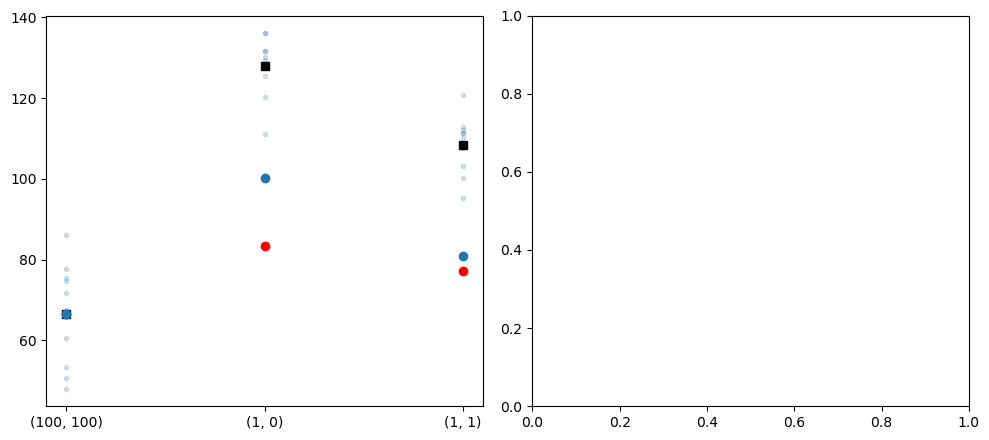

In [62]:
# Visualizer

plt.figure(figsize=(10, 4.5))

plt.subplot(121)
# plt.title(f"Figure 2.7.1{letter}. The effect of imperfect relocations ({distribution} demand)", loc='left', pad=15)

plt.plot([str(c) for c in combos] * cfg.n_experiments, cm2_memory.flatten(), '.', color="tab:blue",
        alpha=0.2, label="Individual runs")
plt.plot([str(c) for c in combos], cm2_memory.mean(axis=0), 'ks', label="Average")
base = cm2_memory.mean(axis=0)[0]
plt.plot([str(c) for c in combos], base + effect1_memory.mean(axis=0), 'ro', label="Effect 1")
plt.plot([str(c) for c in combos], base + effect2_memory.mean(axis=0), 'o',
         color="tab:blue", label="Effect 2")
# plt.xlabel("Scenario")
# plt.xticks([0, 1, 2, 3], [translator[scenario] for scenario in scenarios])
# plt.ylabel("CM2 per day, Eur");
# plt.grid(alpha=0.1)
# plt.legend(loc="upper right")

plt.subplot(122)
# plt.plot([0,1,2,3]*cfg.n_experiments, memory_n_relos.flatten()/memory_n_rentals.flatten()*1000,
#         '.', color="tab:blue", alpha=0.2, label="Individual runs")
# plt.plot([0, 1, 2, 3], memory_n_relos.mean(axis=0)/memory_n_rentals.mean(axis=0)*1000,
#         'ks-', label="Average", linewidth=0.1)
# plt.xlabel("Scenario")
# plt.xticks([0, 1, 2, 3], [translator[scenario] for scenario in scenarios])
# plt.ylabel("Relocations per 1000 rentals");
# plt.grid(alpha=0.1)

plt.tight_layout()

# plt.savefig(f"../figures/02relos_10.svg", dpi=300)